<a href="https://colab.research.google.com/github/juli-ter/COINS/blob/main/ELR_LMM_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear mixed-effects analysis of Evoked Learning Rate (ELR)

This notebook is adapted to the structure of `elr_long.csv`.

The primary model is:

\[
ELR ∼ volatility × noise + jump size + (1 ¦ subject)
\]

Here:

- `elr` is the dependent variable;
- `volatility` has two levels: stable and volatile;
- `noise` has three levels: low, medium, and high;
- `jump_size` is included as a covariate and standardized before modelling;
- `(1 | subject)` accounts for repeated observations from the same participant;
- only rows with `valid_for_model == TRUE` are included.




In [ ]:
# Install required packages if necessary.
required_packages <- c(
  "readr",
  "dplyr",
  "tidyr",
  "ggplot2",
  "lme4",
  "lmerTest",
  "emmeans",
  "sjPlot",
  "performance",
  "see"
)

missing_packages <- required_packages[
  !required_packages %in% rownames(installed.packages())
]

if (length(missing_packages) > 0) {
  install.packages(
    missing_packages,
    repos = "https://cloud.r-project.org"
  )
}


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘numDeriv’, ‘estimability’, ‘mvtnorm’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’, ‘correlation’, ‘effectsize’, ‘modelbased’, ‘patchwork’




In [ ]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(emmeans)
library(sjPlot)
library(performance)
library(see)

# Larger plots inside a Jupyter / Colab R notebook
options(
  repr.plot.width = 11,
  repr.plot.height = 7,
  repr.plot.res = 150
)

theme_set(
  theme_minimal(base_size = 15)
)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




## 1. Load the ELR data


In [ ]:
candidate_paths <- c(
  "elr_long.csv",
  "/content/elr_long.csv"
)

data_path <- candidate_paths[file.exists(candidate_paths)][1]

if (is.na(data_path)) {
  stop(
    "elr_long.csv was not found. ",
    "Place it in the notebook folder or upload it to /content/."
  )
}

dataset <- read_csv(
  data_path,
  show_col_types = FALSE
)


dataset <- dataset %>%
  filter(noise != "medium")

cat("Loaded:", data_path, "\n")
cat("Rows:", nrow(dataset), "\n")
cat("Participants:", n_distinct(dataset$subject), "\n")

head(dataset)


Loaded: elr_long.csv 
Rows: 352 
Participants: 22 


subject,session,volatility,noise,noise_deg,n_changepoints,jump_size,pre_baseline_lr,post_peak_lr,peak_relative_beam,post_mean_lr,elr,elr_mean_change,median_event_elr,valid_for_model
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
sub-01,1,stable,low,10,10,34.00000,-0.04273622,0.3457270,4,0.1828816,0.38846326,0.22561786,0.8896297,TRUE
sub-01,1,stable,high,30,6,33.33333,0.14125972,0.5217391,4,0.0879987,0.38047941,-0.05326103,0.6409224,TRUE
sub-01,1,volatile,low,10,30,29.66667,0.24487391,0.4775362,9,0.1860588,0.23266224,-0.05881516,0.6381313,TRUE
sub-01,1,volatile,high,30,18,26.11111,0.15861584,0.2506034,2,0.1200594,0.09198755,-0.03855640,0.6135816,TRUE
sub-01,2,stable,low,10,11,27.27273,0.08643847,0.5022986,4,0.1532965,0.41586015,0.06685801,0.8894737,TRUE
sub-01,2,stable,high,30,8,38.75000,0.05093491,0.5223927,3,0.1805956,0.47145783,0.12966070,0.8024229,TRUE


In [ ]:
required_columns <- c(
  "subject",
  "session",
  "volatility",
  "noise",
  "noise_deg",
  "n_changepoints",
  "jump_size",
  "elr",
  "elr_mean_change",
  "valid_for_model"
)

missing_columns <- setdiff(
  required_columns,
  colnames(dataset)
)

if (length(missing_columns) > 0) {
  stop(
    "Missing required columns: ",
    paste(missing_columns, collapse = ", ")
  )
}

colnames(dataset)


[1] "subject"            "session"            "volatility"        
 [4] "noise"              "noise_deg"          "n_changepoints"    
 [7] "jump_size"          "pre_baseline_lr"    "post_peak_lr"      
[10] "peak_relative_beam" "post_mean_lr"       "elr"               
[13] "elr_mean_change"    "median_event_elr"   "valid_for_model"

## 2. Prepare the data

The file contains both valid and invalid condition-level ELR estimates.  
The primary LMM uses only rows marked `valid_for_model`.


In [ ]:
dataset <- dataset %>%
  mutate(
    subject = factor(subject),

    session = factor(session),

    volatility = factor(
      tolower(trimws(as.character(volatility))),
      levels = c("stable", "volatile")
    ),

    noise = factor(
      tolower(trimws(as.character(noise))),
      levels = c("low", "high")
    ),

    valid_for_model = (
      tolower(as.character(valid_for_model))
      %in% c("true", "1", "yes")
    ),

    elr = as.numeric(elr),
    elr_mean_change = as.numeric(elr_mean_change),
    jump_size = as.numeric(jump_size),
    n_changepoints = as.numeric(n_changepoints)
  )

dataset[sapply(dataset, is.infinite)] <- NA

cat("Missing values by column:\n")
print(colSums(is.na(dataset)))

cat("\nRows by condition and validity:\n")
print(
  dataset %>%
    count(
      volatility,
      noise,
      valid_for_model
    )
)


Missing values by column:
           subject            session         volatility              noise 
                 0                  0                  0                  0 
         noise_deg     n_changepoints          jump_size    pre_baseline_lr 
                 0                  0                  0                  0 
      post_peak_lr peak_relative_beam       post_mean_lr                elr 
                 0                  0                  0                  0 
   elr_mean_change   median_event_elr    valid_for_model 
                 0                  0                  0 

Rows by condition and validity:
# A tibble: 5 × 4
  volatility noise valid_for_model     n
  <fct>      <fct> <lgl>           <int>
1 stable     low   TRUE               88
2 stable     high  FALSE              21
3 stable     high  TRUE               67
4 volatile   low   TRUE               88
5 volatile   high  TRUE               88


In [ ]:
elr_data <- dataset %>%
  filter(
    valid_for_model,
    !is.na(elr),
    is.finite(elr),
    !is.na(jump_size),
    is.finite(jump_size),
    !is.na(subject),
    !is.na(volatility),
    !is.na(noise)
  ) %>%
  mutate(
    jump_size_z = as.numeric(
      scale(jump_size)
    )
  )

# Sum coding for factorial Type-III tests
contrasts(elr_data$volatility) <- contr.sum(2)
contrasts(elr_data$noise) <- contr.sum(2)

cat("Rows used in the ELR model:", nrow(elr_data), "\n")
cat("Participants used:", n_distinct(elr_data$subject), "\n")

elr_data %>%
  group_by(
    volatility,
    noise
  ) %>%
  summarise(
    n = n(),
    mean_elr = mean(elr),
    median_elr = median(elr),
    sd_elr = sd(elr),
    mean_changepoints = mean(n_changepoints),
    mean_jump_size = mean(jump_size),
    .groups = "drop"
  )


Rows used in the ELR model: 331 
Participants used: 22 


volatility,noise,n,mean_elr,median_elr,sd_elr,mean_changepoints,mean_jump_size
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stable,low,88,0.2622498,0.2479104,0.12126420,10.375000,31.05195
stable,high,67,0.2851555,0.2529298,0.12363349,6.343284,33.24698
volatile,low,88,0.1622193,0.1656723,0.08081099,32.875000,30.47195
volatile,high,88,0.2213804,0.1962548,0.11648886,15.443182,28.01536


## 3. Descriptive plots


In [ ]:
output_dir <- "elr_lmm_outputs"

dir.create(
  output_dir,
  showWarnings = FALSE,
  recursive = TRUE
)


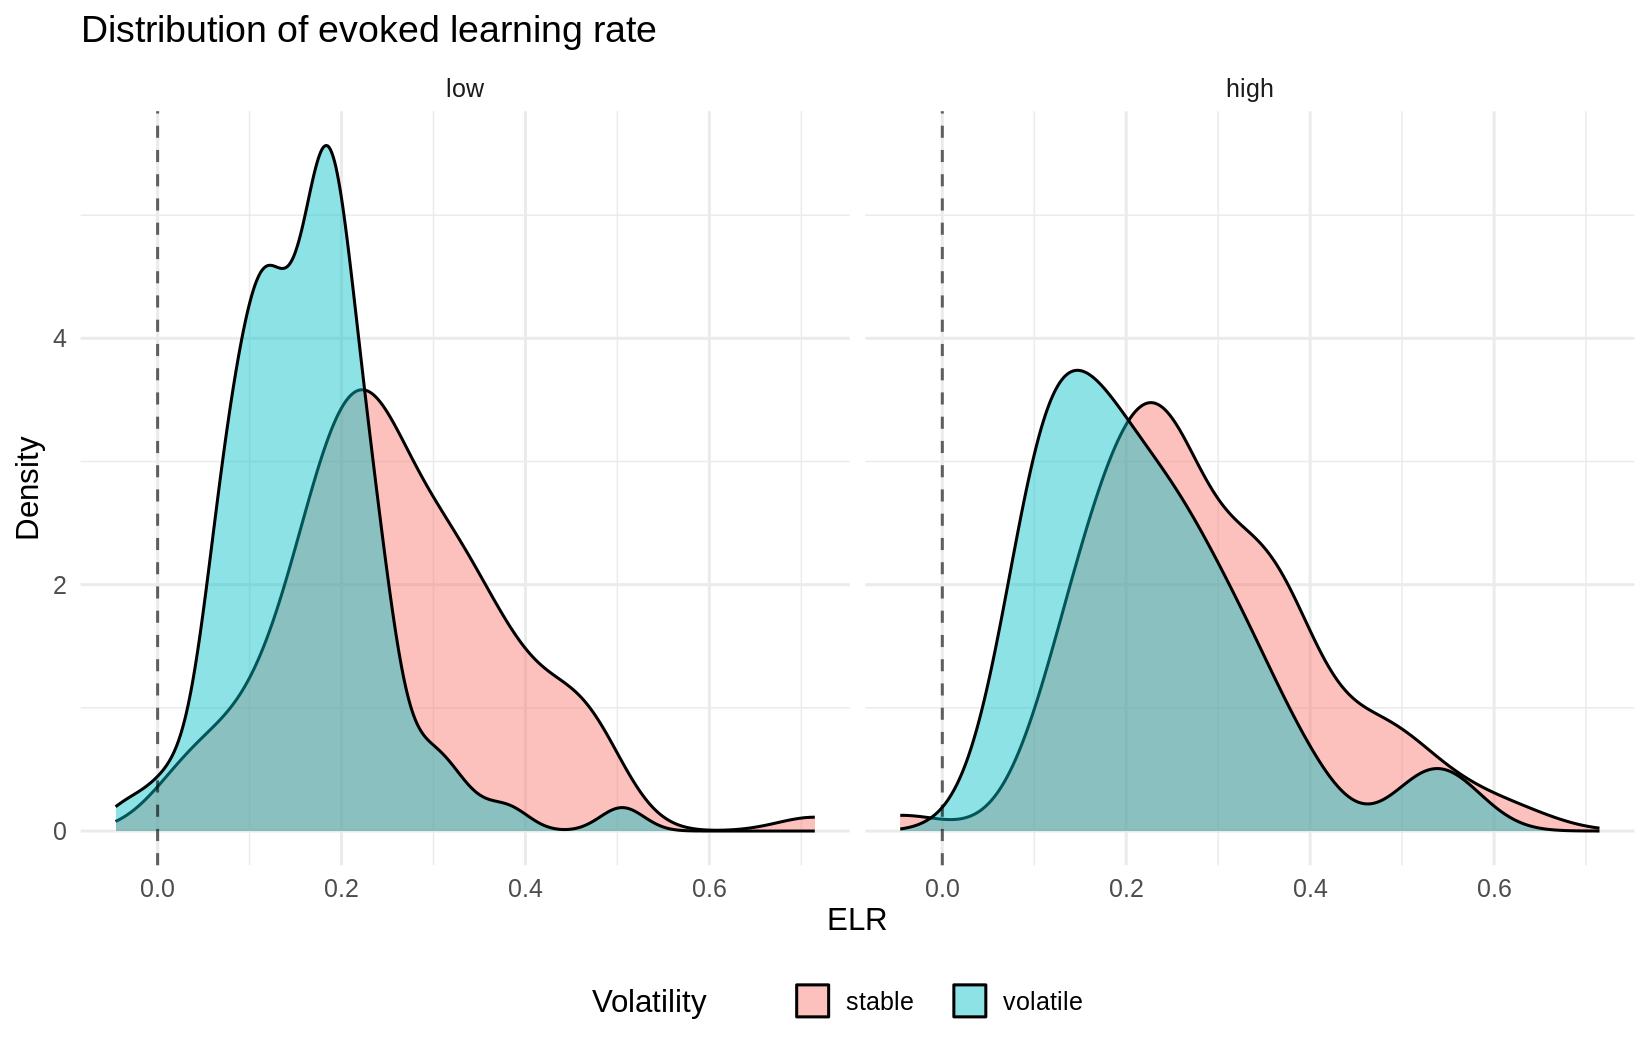

In [ ]:
# Distribution of ELR values
p_density <- ggplot(
  elr_data,
  aes(
    x = elr,
    fill = volatility
  )
) +
  geom_density(
    alpha = 0.45
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed",
    alpha = 0.6
  ) +
  labs(
    title = "Distribution of evoked learning rate",
    x = "ELR",
    y = "Density",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_density

ggsave(
  file.path(
    output_dir,
    "elr_density.png"
  ),
  p_density,
  width = 12,
  height = 5,
  dpi = 300
)


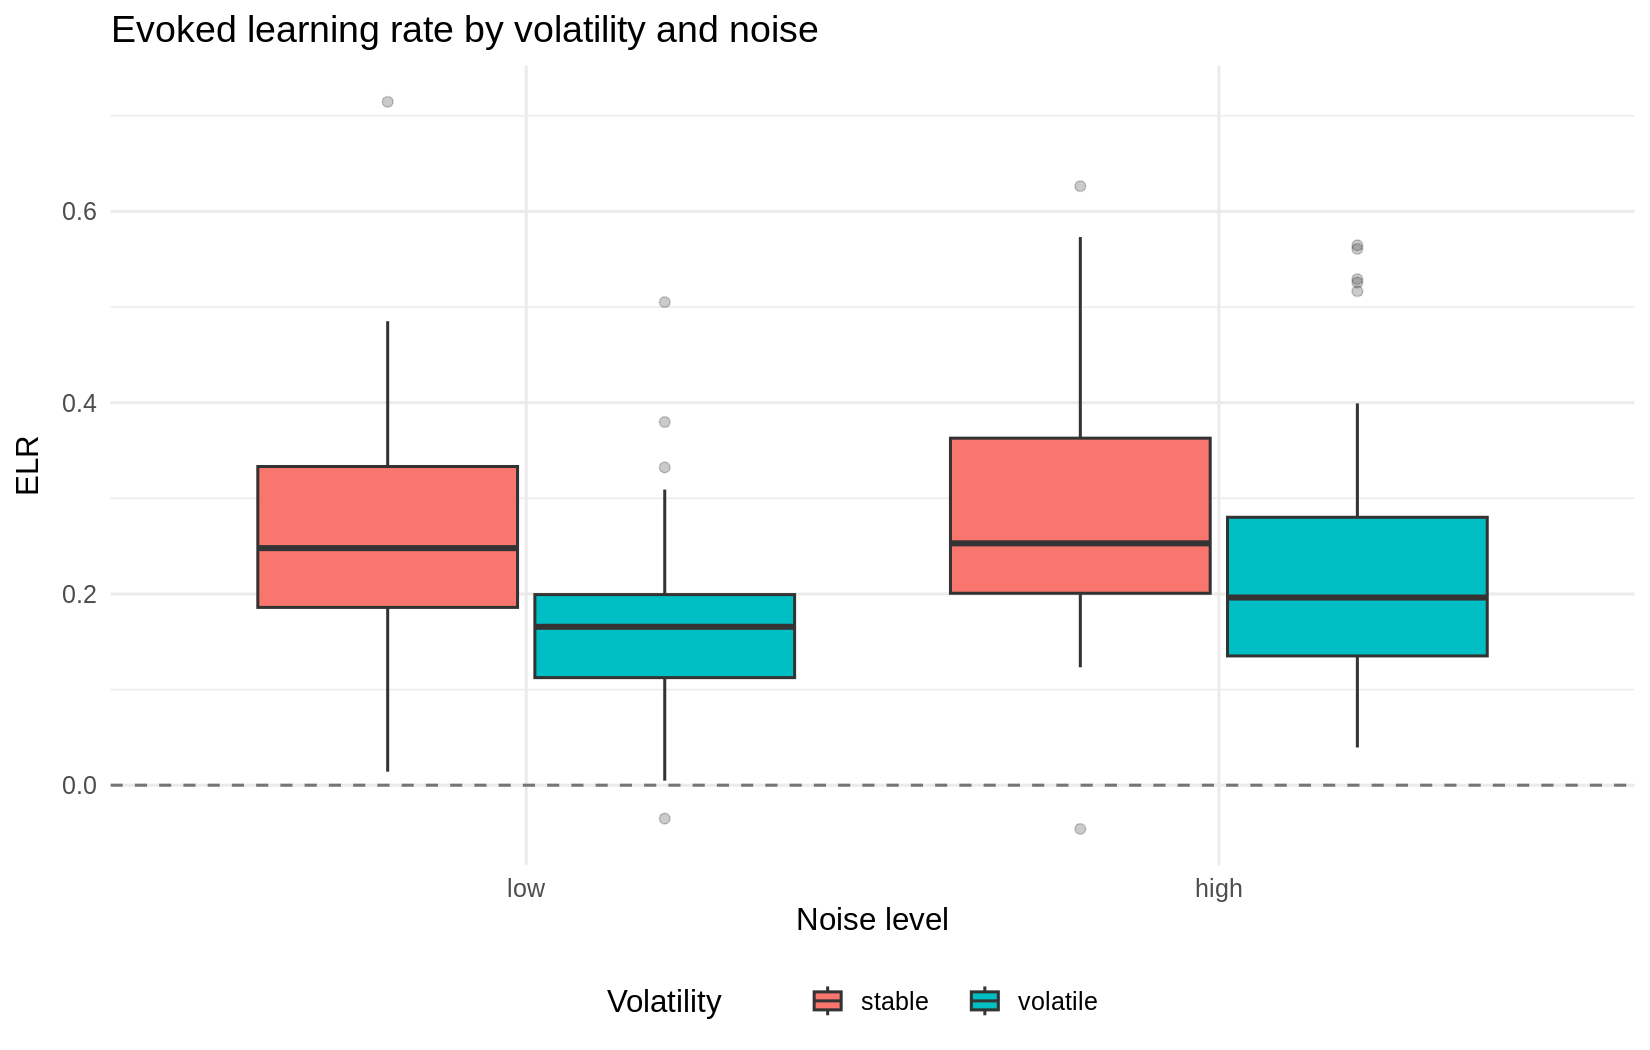

In [ ]:
# Raw ELR by experimental condition
p_box <- ggplot(
  elr_data,
  aes(
    x = noise,
    y = elr,
    fill = volatility
  )
) +
  geom_boxplot(
    position = position_dodge(width = 0.8),
    outlier.alpha = 0.25
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    alpha = 0.5
  ) +
  labs(
    title = "Evoked learning rate by volatility and noise",
    x = "Noise level",
    y = "ELR",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_box

ggsave(
  file.path(
    output_dir,
    "elr_boxplot.png"
  ),
  p_box,
  width = 9,
  height = 6,
  dpi = 300
)


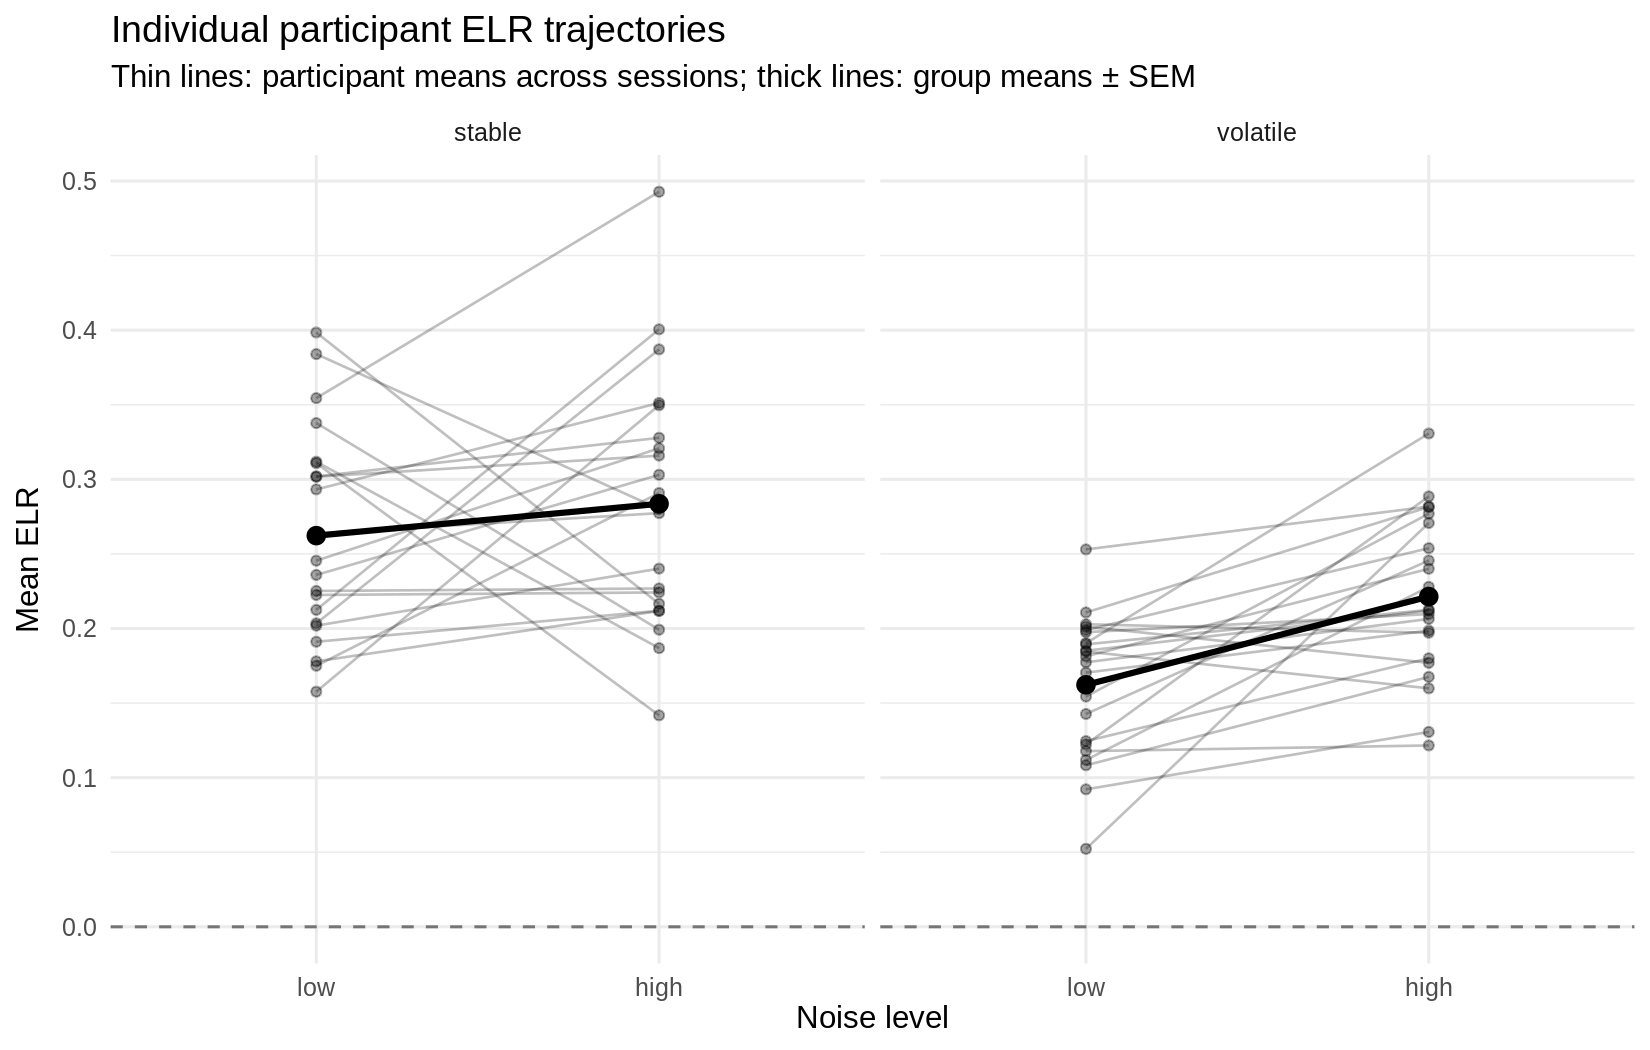

In [ ]:
# Participant-level condition means averaged across sessions
participant_means <- elr_data %>%
  group_by(
    subject,
    volatility,
    noise
  ) %>%
  summarise(
    mean_elr = mean(
      elr,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

group_means <- participant_means %>%
  group_by(
    volatility,
    noise
  ) %>%
  summarise(
    mean_elr = mean(
      mean_elr,
      na.rm = TRUE
    ),
    se_elr = sd(
      mean_elr,
      na.rm = TRUE
    ) / sqrt(
      sum(!is.na(mean_elr))
    ),
    .groups = "drop"
  )

p_individual <- ggplot() +

  geom_line(
    data = participant_means,
    aes(
      x = noise,
      y = mean_elr,
      group = subject
    ),
    alpha = 0.25,
    linewidth = 0.6
  ) +

  geom_point(
    data = participant_means,
    aes(
      x = noise,
      y = mean_elr,
      group = subject
    ),
    alpha = 0.35,
    size = 1.8
  ) +

  geom_line(
    data = group_means,
    aes(
      x = noise,
      y = mean_elr,
      group = 1
    ),
    linewidth = 1.4
  ) +

  geom_point(
    data = group_means,
    aes(
      x = noise,
      y = mean_elr
    ),
    size = 3.5
  ) +

  geom_errorbar(
    data = group_means,
    aes(
      x = noise,
      ymin = mean_elr - se_elr,
      ymax = mean_elr + se_elr
    ),
    width = 0.08,
    linewidth = 0.8
  ) +

  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    alpha = 0.5
  ) +

  facet_wrap(
    ~ volatility
  ) +

  labs(
    title = "Individual participant ELR trajectories",
    subtitle = "Thin lines: participant means across sessions; thick lines: group means ± SEM",
    x = "Noise level",
    y = "Mean ELR"
  )

p_individual

ggsave(
  file.path(
    output_dir,
    "elr_individual_trajectories.png"
  ),
  p_individual,
  width = 12,
  height = 7,
  dpi = 300
)


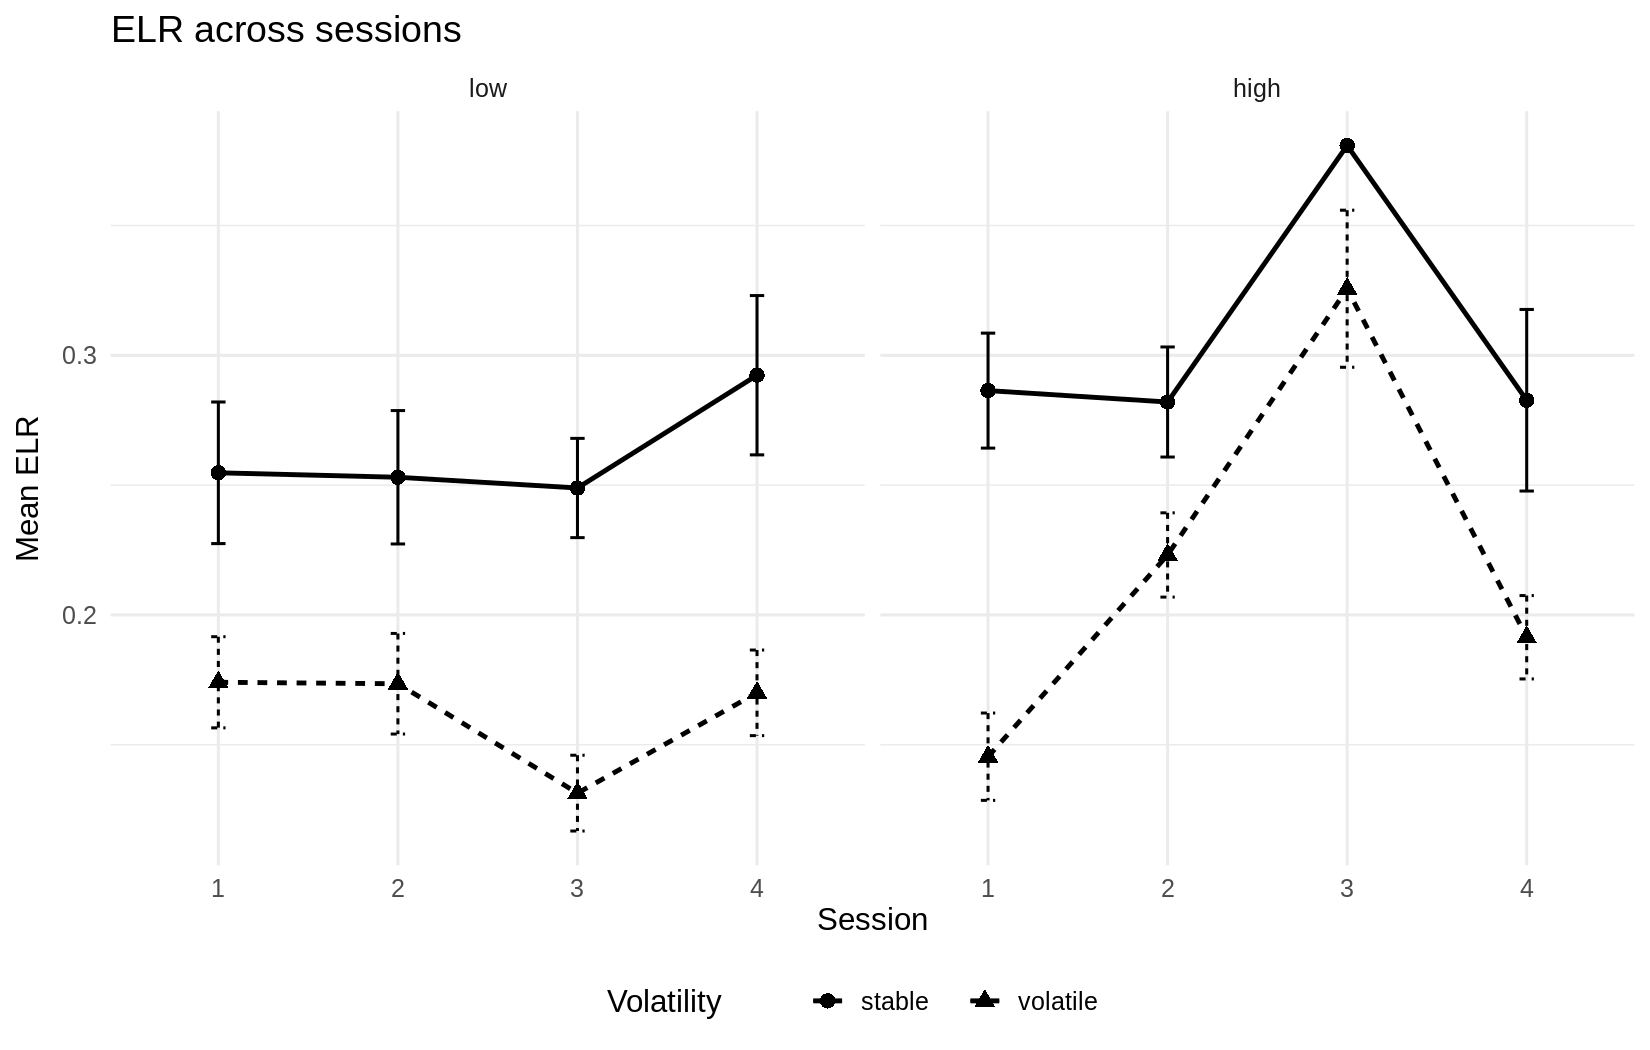

In [ ]:
# Descriptive session plot
session_means <- elr_data %>%
  group_by(
    session,
    volatility,
    noise
  ) %>%
  summarise(
    mean_elr = mean(elr),
    se_elr = sd(elr) / sqrt(n()),
    .groups = "drop"
  )

p_session <- ggplot(
  session_means,
  aes(
    x = session,
    y = mean_elr,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.1
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = mean_elr - se_elr,
      ymax = mean_elr + se_elr
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  labs(
    title = "ELR across sessions",
    x = "Session",
    y = "Mean ELR",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_session

ggsave(
  file.path(
    output_dir,
    "elr_across_sessions.png"
  ),
  p_session,
  width = 12,
  height = 5,
  dpi = 300
)


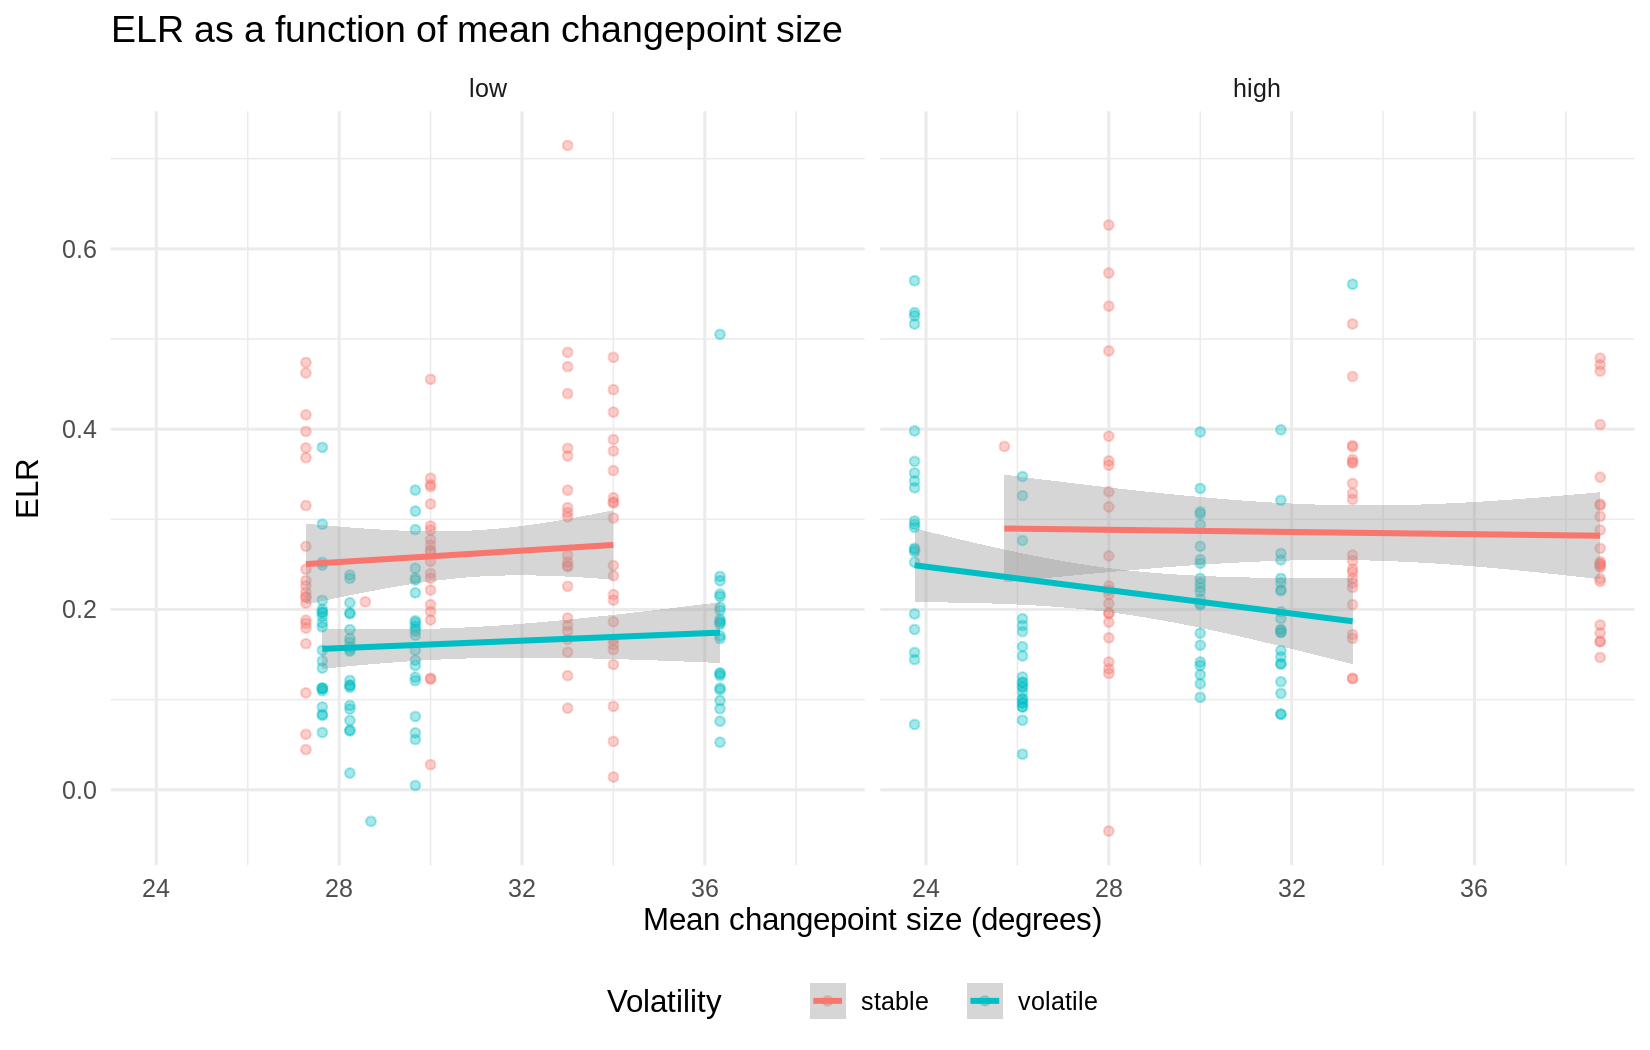

In [ ]:
# Relationship between mean changepoint size and ELR
p_jump <- ggplot(
  elr_data,
  aes(
    x = jump_size,
    y = elr,
    colour = volatility
  )
) +
  geom_point(
    alpha = 0.35,
    size = 1.7
  ) +
  geom_smooth(
    method = "lm",
    formula = y ~ x,
    se = TRUE
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  labs(
    title = "ELR as a function of mean changepoint size",
    x = "Mean changepoint size (degrees)",
    y = "ELR",
    colour = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_jump

ggsave(
  file.path(
    output_dir,
    "elr_by_jump_size.png"
  ),
  p_jump,
  width = 12,
  height = 5,
  dpi = 300
)


## 4. Fit the linear mixed-effects model

The primary model is:

\[
ELR \sim volatility \times noise + jump\ size_z + (1 \mid subject)
\]

`volatility * noise` includes:

- the main effect of volatility;
- the main effect of noise;
- the volatility × noise interaction.

`jump_size_z` controls for differences in the mean changepoint magnitude contributing to each ELR estimate.


In [ ]:
model_elr <- lmer(
  elr ~
    volatility * noise +
    jump_size_z +
    (1 | subject),
  data = elr_data,
  REML = FALSE
)

summary(model_elr)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: elr ~ volatility * noise + jump_size_z + (1 | subject)
   Data: elr_data

      AIC       BIC    logLik -2*log(L)  df.resid 
   -514.0    -487.4     264.0    -528.0       324 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8660 -0.6617 -0.1026  0.5303  4.2125 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.000942 0.03069 
 Residual             0.011251 0.10607 
Number of obs: 331, groups:  subject, 22

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)          0.232861   0.008796  22.258372  26.474  < 2e-16 ***
volatility1          0.041864   0.006370 308.992812   6.572 2.11e-10 ***
noise1              -0.020485   0.005872 309.017521  -3.488 0.000557 ***
jump_size_z         -0.002411   0.006597 308.947733  -0.365 0.715051    
volatility1:noise1   0.008332   0.006196 308.998263 

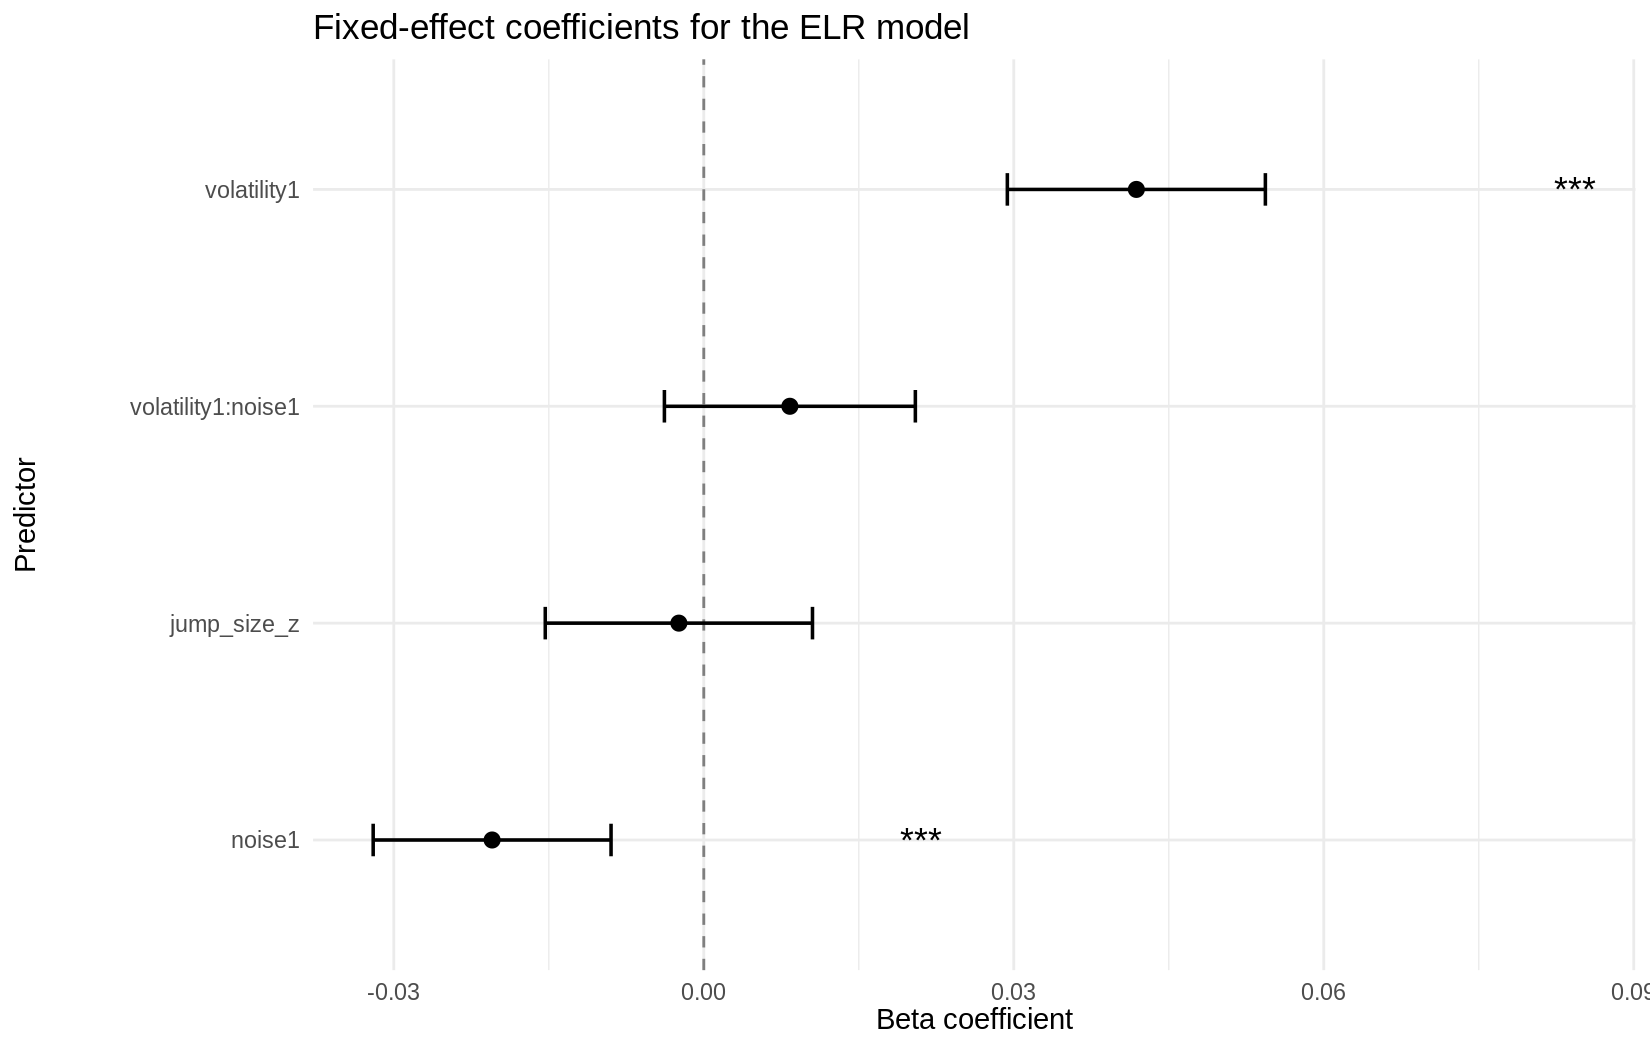

In [ ]:
library(dplyr)
library(ggplot2)

# Extract fixed effects from the model
beta_plot_data <- as.data.frame(
  summary(model_elr)$coefficients
)

beta_plot_data$Effect <- rownames(beta_plot_data)
rownames(beta_plot_data) <- NULL

beta_plot_data <- beta_plot_data %>%
  select(
    Effect,
    Estimate,
    `Std. Error`,
    `Pr(>|t|)`
  ) %>%
  rename(
    Beta = Estimate,
    SE = `Std. Error`,
    p = `Pr(>|t|)`
  ) %>%
  mutate(
    CI_low = Beta - 1.96 * SE,
    CI_high = Beta + 1.96 * SE,
    Significance = case_when(
      p < 0.001 ~ "***",
      p < 0.01  ~ "**",
      p < 0.05  ~ "*",
      TRUE      ~ ""
    )
  )

# Optional: remove intercept if you only want predictors
beta_plot_data_no_intercept <- beta_plot_data %>%
  filter(Effect != "(Intercept)")

# Plot
p_beta <- ggplot(
  beta_plot_data_no_intercept,
  aes(
    x = reorder(Effect, Beta),
    y = Beta
  )
) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    color = "grey50"
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = CI_low,
      ymax = CI_high
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_text(
    aes(
      label = Significance,
      y = CI_high + 0.03
    ),
    size = 6
  ) +
  coord_flip() +
  labs(
    title = "Fixed-effect coefficients for the ELR model",
    x = "Predictor",
    y = "Beta coefficient"
  ) +
  theme_minimal(
    base_size = 14
  )

p_beta

In [ ]:
# Type-III omnibus tests with Satterthwaite degrees of freedom
anova_elr <- anova(
  model_elr,
  type = 3,
  ddf = "Satterthwaite"
)

anova_elr


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,0.485920823,0.485920823,1,308.9928,43.188895,2.111517e-10
noise,0.136912090,0.136912090,1,309.0175,12.168817,5.565101e-04
jump_size_z,0.001502343,0.001502343,1,308.9477,0.133529,7.150508e-01
volatility:noise,0.020347461,0.020347461,1,308.9983,1.808493,1.796754e-01


In [ ]:
cat(
  "Model converged:",
  is.null(model_elr@optinfo$conv$lme4$messages),
  "\n"
)

cat(
  "Singular fit:",
  isSingular(
    model_elr,
    tol = 1e-4
  ),
  "\n"
)


Model converged: TRUE 
Singular fit: FALSE 


## 5. Estimated marginal means and interaction plot

Estimated marginal means are evaluated at `jump_size_z = 0`, corresponding to the average mean changepoint size in the modelled data.

Because ELR is modelled on its original scale, **no back-transformation is required**.


In [ ]:
emm_elr <- emmeans(
  model_elr,
  ~ volatility * noise,
  at = list(
    jump_size_z = 0
  )
)

emm_elr_df <- as.data.frame(
  confint(emm_elr)
)

emm_elr_df


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,volatility,noise,emmean,SE,df,lower.CL,upper.CL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stable,low,0.2625712,0.01309366,98.71862,0.2365897,0.2885528
2,volatile,low,0.1621802,0.01306451,97.99529,0.1362541,0.1881064
3,stable,high,0.2868784,0.01523492,155.20773,0.2567838,0.3169729
4,volatile,high,0.2198145,0.01374895,115.45596,0.1925816,0.2470474


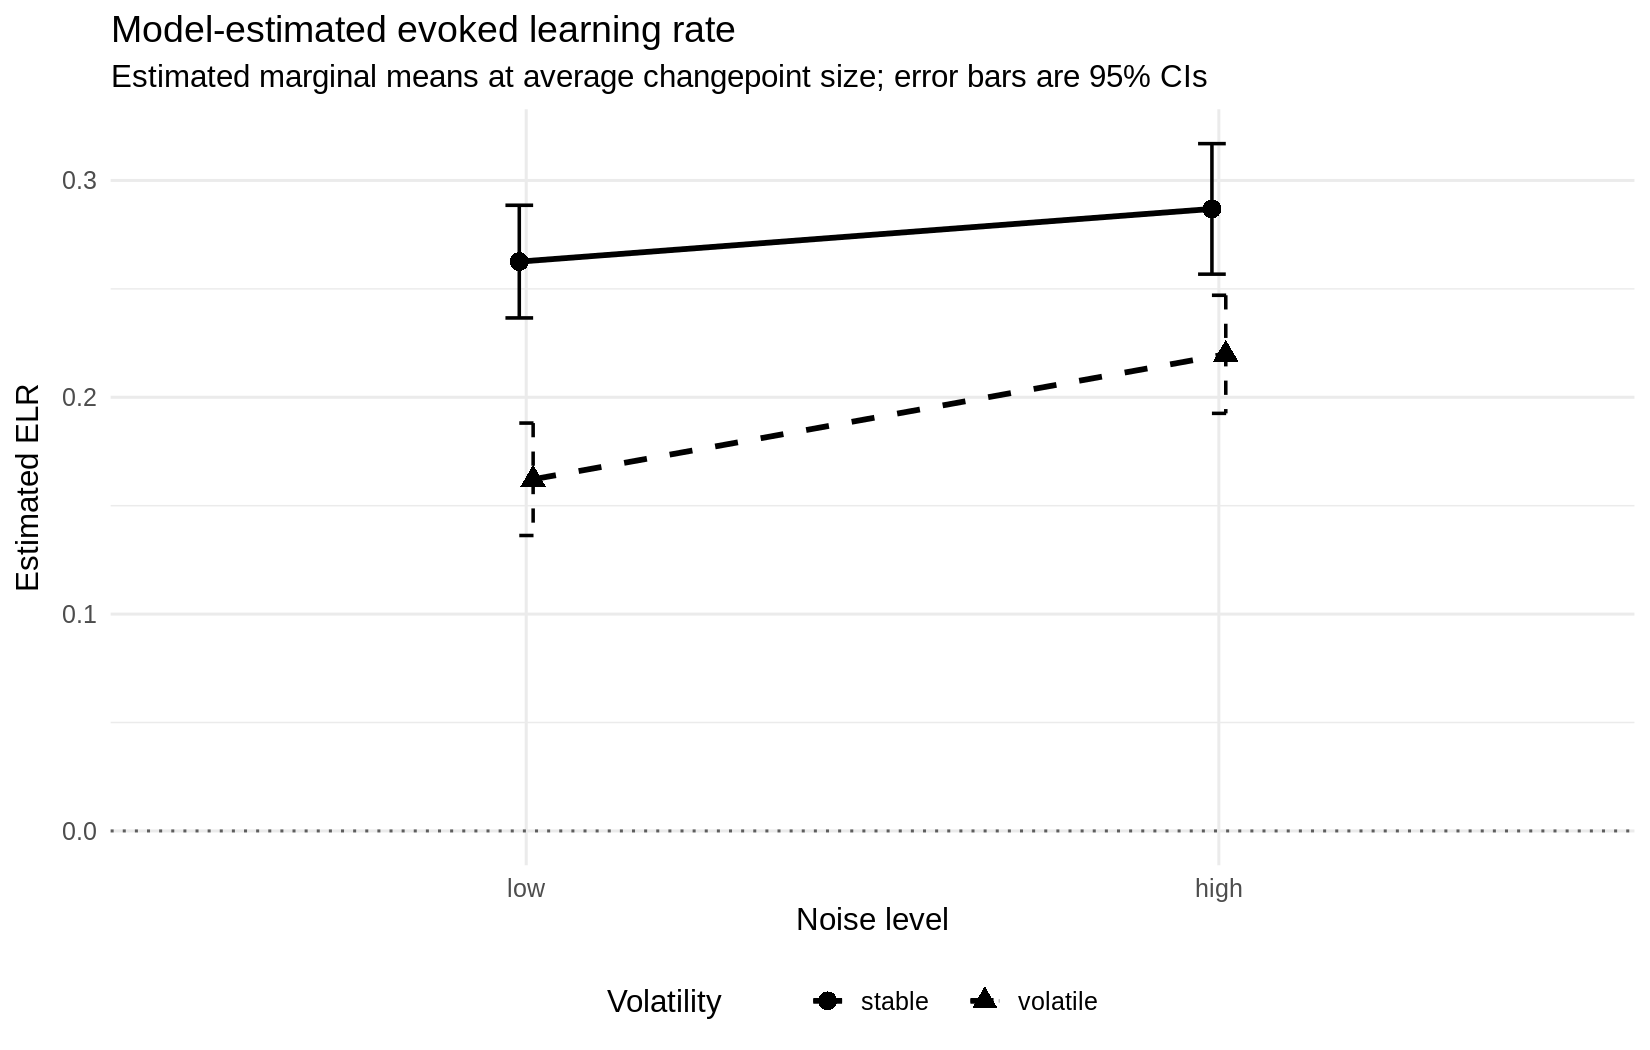

In [ ]:
p_interaction <- ggplot(
  emm_elr_df,
  aes(
    x = noise,
    y = emmean,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.3,
    position = position_dodge(width = 0.04)
  ) +
  geom_point(
    size = 3.8,
    position = position_dodge(width = 0.04)
  ) +
  geom_errorbar(
    aes(
      ymin = lower.CL,
      ymax = upper.CL
    ),
    width = 0.08,
    linewidth = 0.8,
    position = position_dodge(width = 0.04)
  ) +
  scale_linetype_manual(
    values = c(
      stable = "solid",
      volatile = "dashed"
    )
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dotted",
    alpha = 0.6
  ) +
  labs(
    title = "Model-estimated evoked learning rate",
    subtitle = "Estimated marginal means at average changepoint size; error bars are 95% CIs",
    x = "Noise level",
    y = "Estimated ELR",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_interaction

ggsave(
  file.path(
    output_dir,
    "elr_lmm_interaction.png"
  ),
  p_interaction,
  width = 10,
  height = 7,
  dpi = 300
)

ggsave(
  file.path(
    output_dir,
    "elr_lmm_interaction.pdf"
  ),
  p_interaction,
  width = 10,
  height = 7
)


## 6. Holm-corrected post-hoc comparisons


In [ ]:
# Stable vs volatile at each noise level
emm_volatility_by_noise <- emmeans(
  model_elr,
  ~ volatility | noise,
  at = list(
    jump_size_z = 0
  )
)

posthoc_volatility <- as.data.frame(
  pairs(
    emm_volatility_by_noise,
    adjust = "holm"
  )
)

posthoc_volatility


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,noise,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stable - volatile,low,0.09897320,0.01640781,484.9694,6.032077,3.213968e-09
2,stable - volatile,medium,0.09604011,0.01712571,484.9702,5.607949,3.443174e-08
3,stable - volatile,high,0.05430716,0.01834341,485.0639,2.960582,3.220994e-03


In [ ]:
# Pairwise noise comparisons within stable and volatile environments
emm_noise_by_volatility <- emmeans(
  model_elr,
  ~ noise | volatility,
  at = list(
    jump_size_z = 0
  )
)

posthoc_noise <- as.data.frame(
  pairs(
    emm_noise_by_volatility,
    adjust = "holm"
  )
)

posthoc_noise


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,volatility,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,low - medium,stable,-0.004799054,0.01802111,484.9710,-0.2663019,0.8846877768
2,low - high,stable,-0.018973300,0.01776446,485.0807,-1.0680483,0.8580898884
3,medium - high,stable,-0.014174246,0.01843514,485.1002,-0.7688713,0.8846877768
4,low - medium,volatile,-0.007732144,0.01668764,484.9697,-0.4633456,0.6433245480
5,low - high,volatile,-0.063639348,0.01656805,484.9695,-3.8410891,0.0004162479
6,medium - high,volatile,-0.055907204,0.01728326,484.9703,-3.2347608,0.0026011004


## 7. Fixed and random effects


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the sjPlot package.
  Please report the issue at <https://github.com/strengejacke/sjPlot/issues>.”


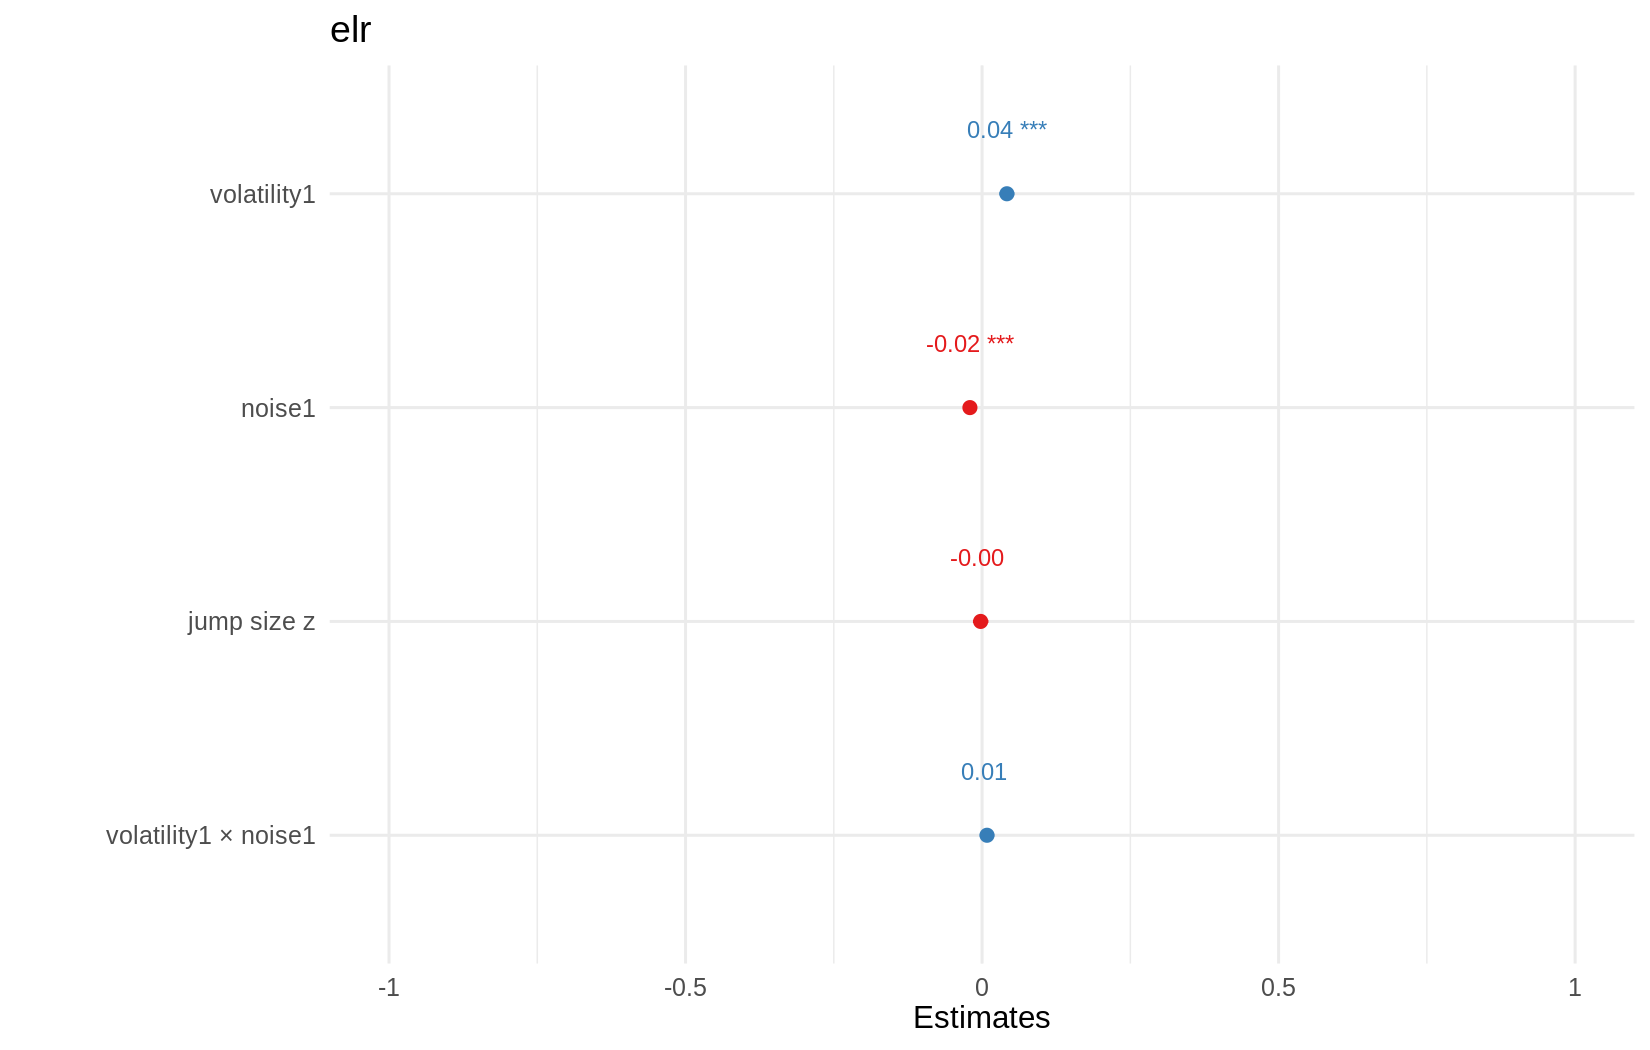

In [ ]:
options(
  repr.plot.width = 11,
  repr.plot.height = 7
)

p_fixed <- plot_model(
  model_elr,
  type = "est",
  show.values = TRUE,
  value.offset = 0.3
)

p_fixed

ggsave(
  file.path(
    output_dir,
    "elr_fixed_effects.png"
  ),
  p_fixed,
  width = 11,
  height = 7,
  dpi = 300
)


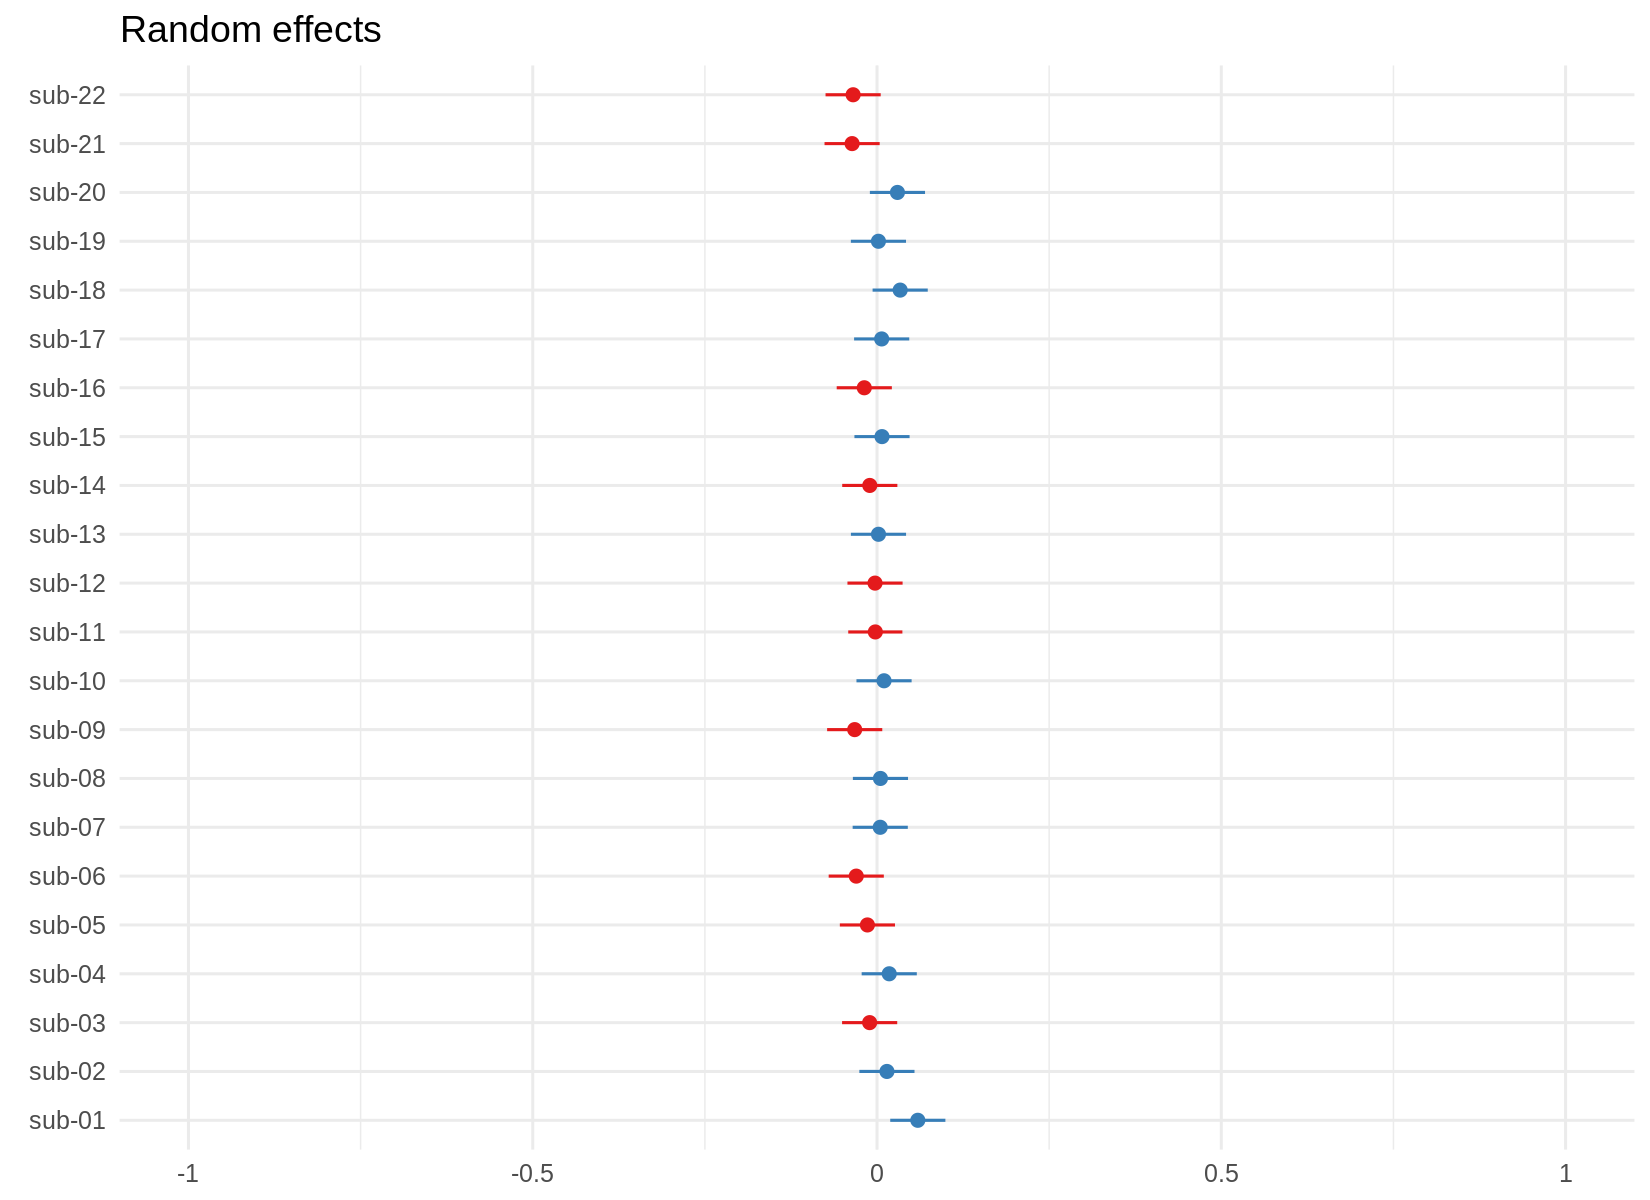

In [ ]:
options(
  repr.plot.width = 11,
  repr.plot.height = 8
)

p_random <- plot_model(
  model_elr,
  type = "re",
  order.terms = TRUE,
  sort.coef = "(Intercept)"
)

p_random

ggsave(
  file.path(
    output_dir,
    "elr_random_intercepts.png"
  ),
  p_random,
  width = 11,
  height = 8,
  dpi = 300
)


## 8. Model diagnostics


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


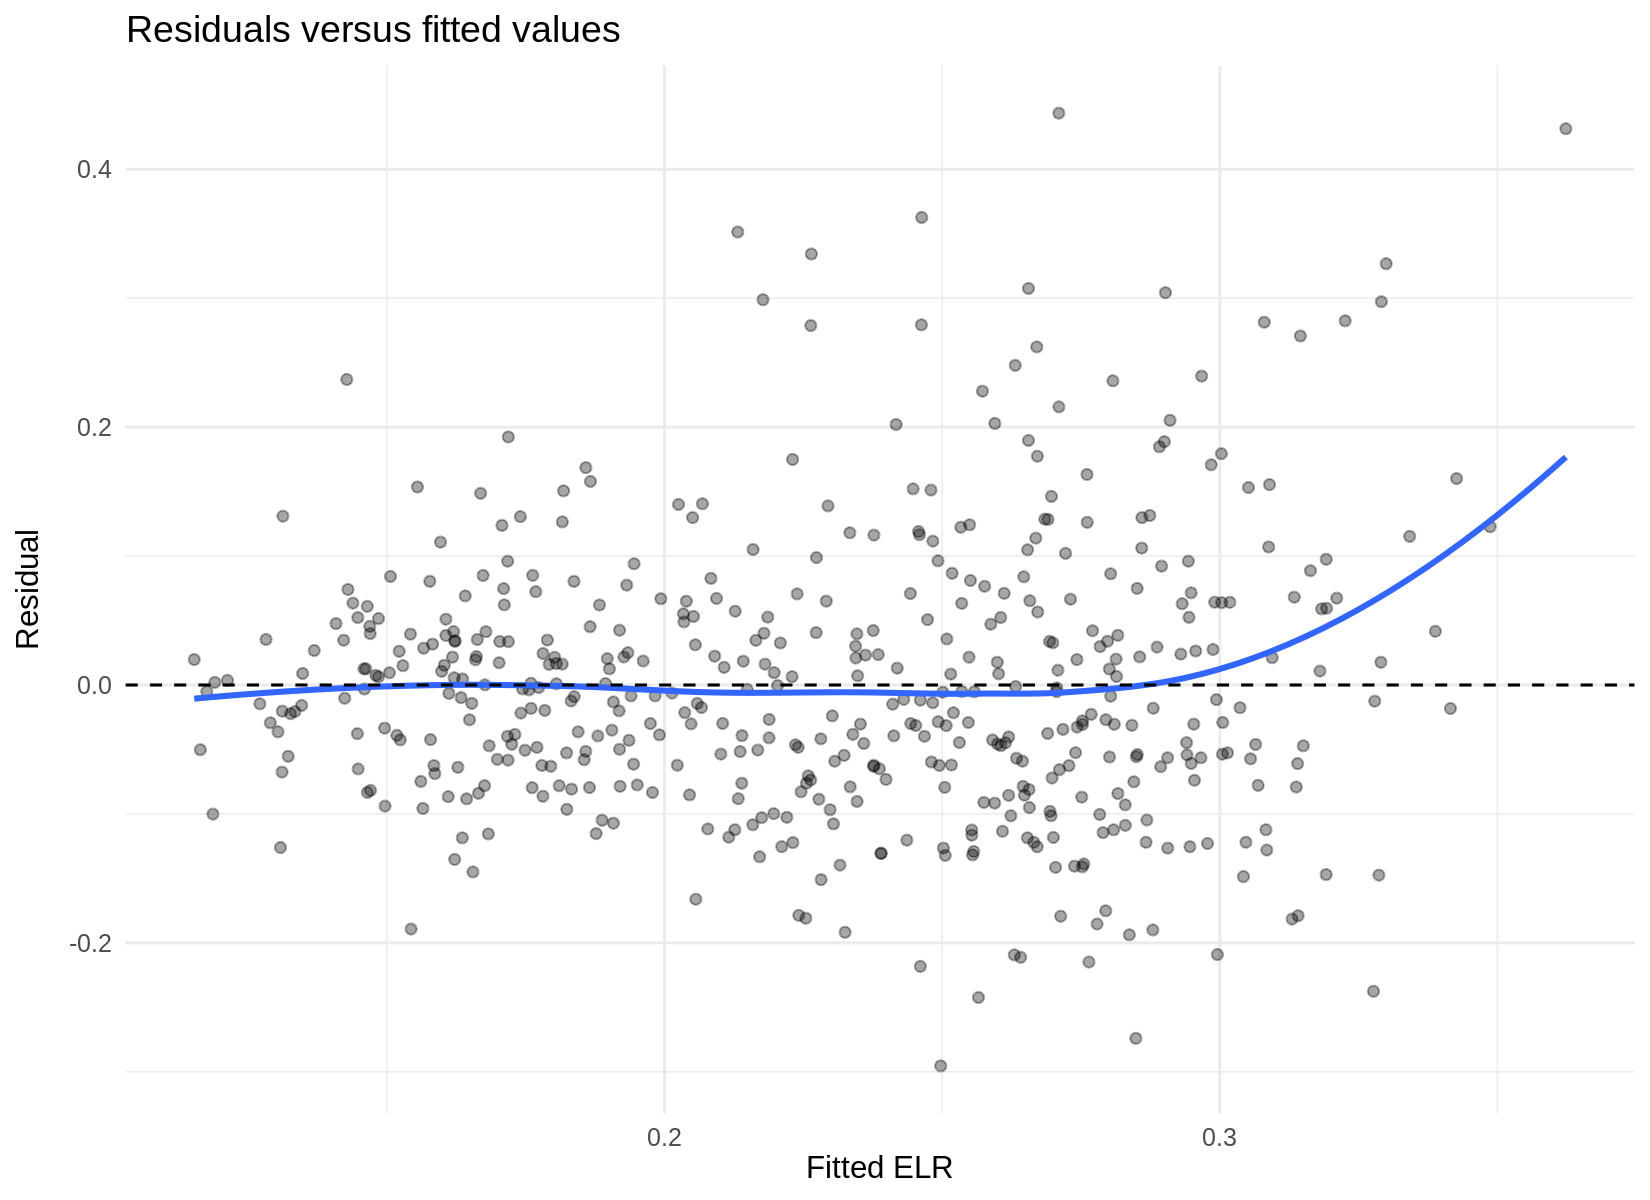

In [ ]:
diagnostic_data <- data.frame(
  fitted = fitted(model_elr),
  residual = resid(model_elr)
)

p_residuals <- ggplot(
  diagnostic_data,
  aes(
    x = fitted,
    y = residual
  )
) +
  geom_point(
    alpha = 0.35
  ) +
  geom_smooth(
    method = "loess",
    se = FALSE
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    title = "Residuals versus fitted values",
    x = "Fitted ELR",
    y = "Residual"
  )

p_residuals

ggsave(
  file.path(
    output_dir,
    "elr_residuals_vs_fitted.png"
  ),
  p_residuals,
  width = 9,
  height = 6,
  dpi = 300
)


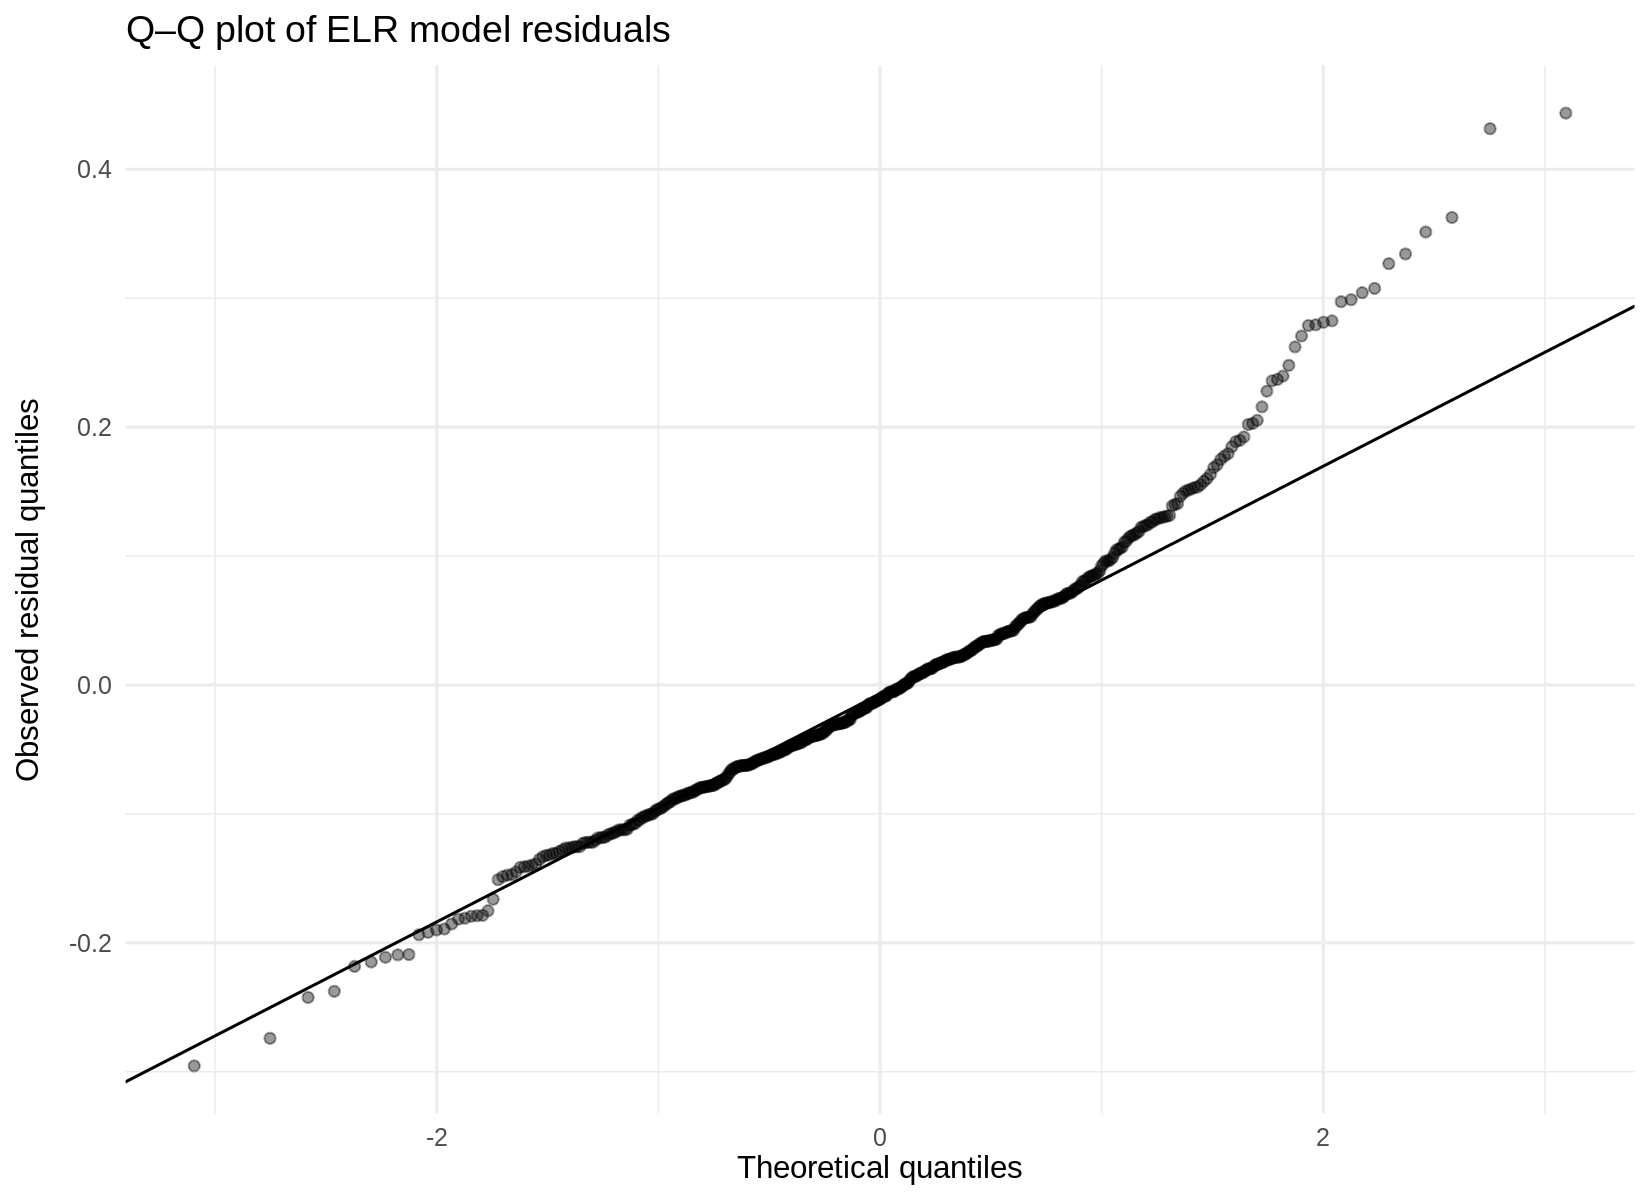

In [ ]:
p_qq <- ggplot(
  diagnostic_data,
  aes(
    sample = residual
  )
) +
  stat_qq(
    alpha = 0.4
  ) +
  stat_qq_line() +
  labs(
    title = "Q–Q plot of ELR model residuals",
    x = "Theoretical quantiles",
    y = "Observed residual quantiles"
  )

p_qq

ggsave(
  file.path(
    output_dir,
    "elr_residuals_qq.png"
  ),
  p_qq,
  width = 9,
  height = 6,
  dpi = 300
)


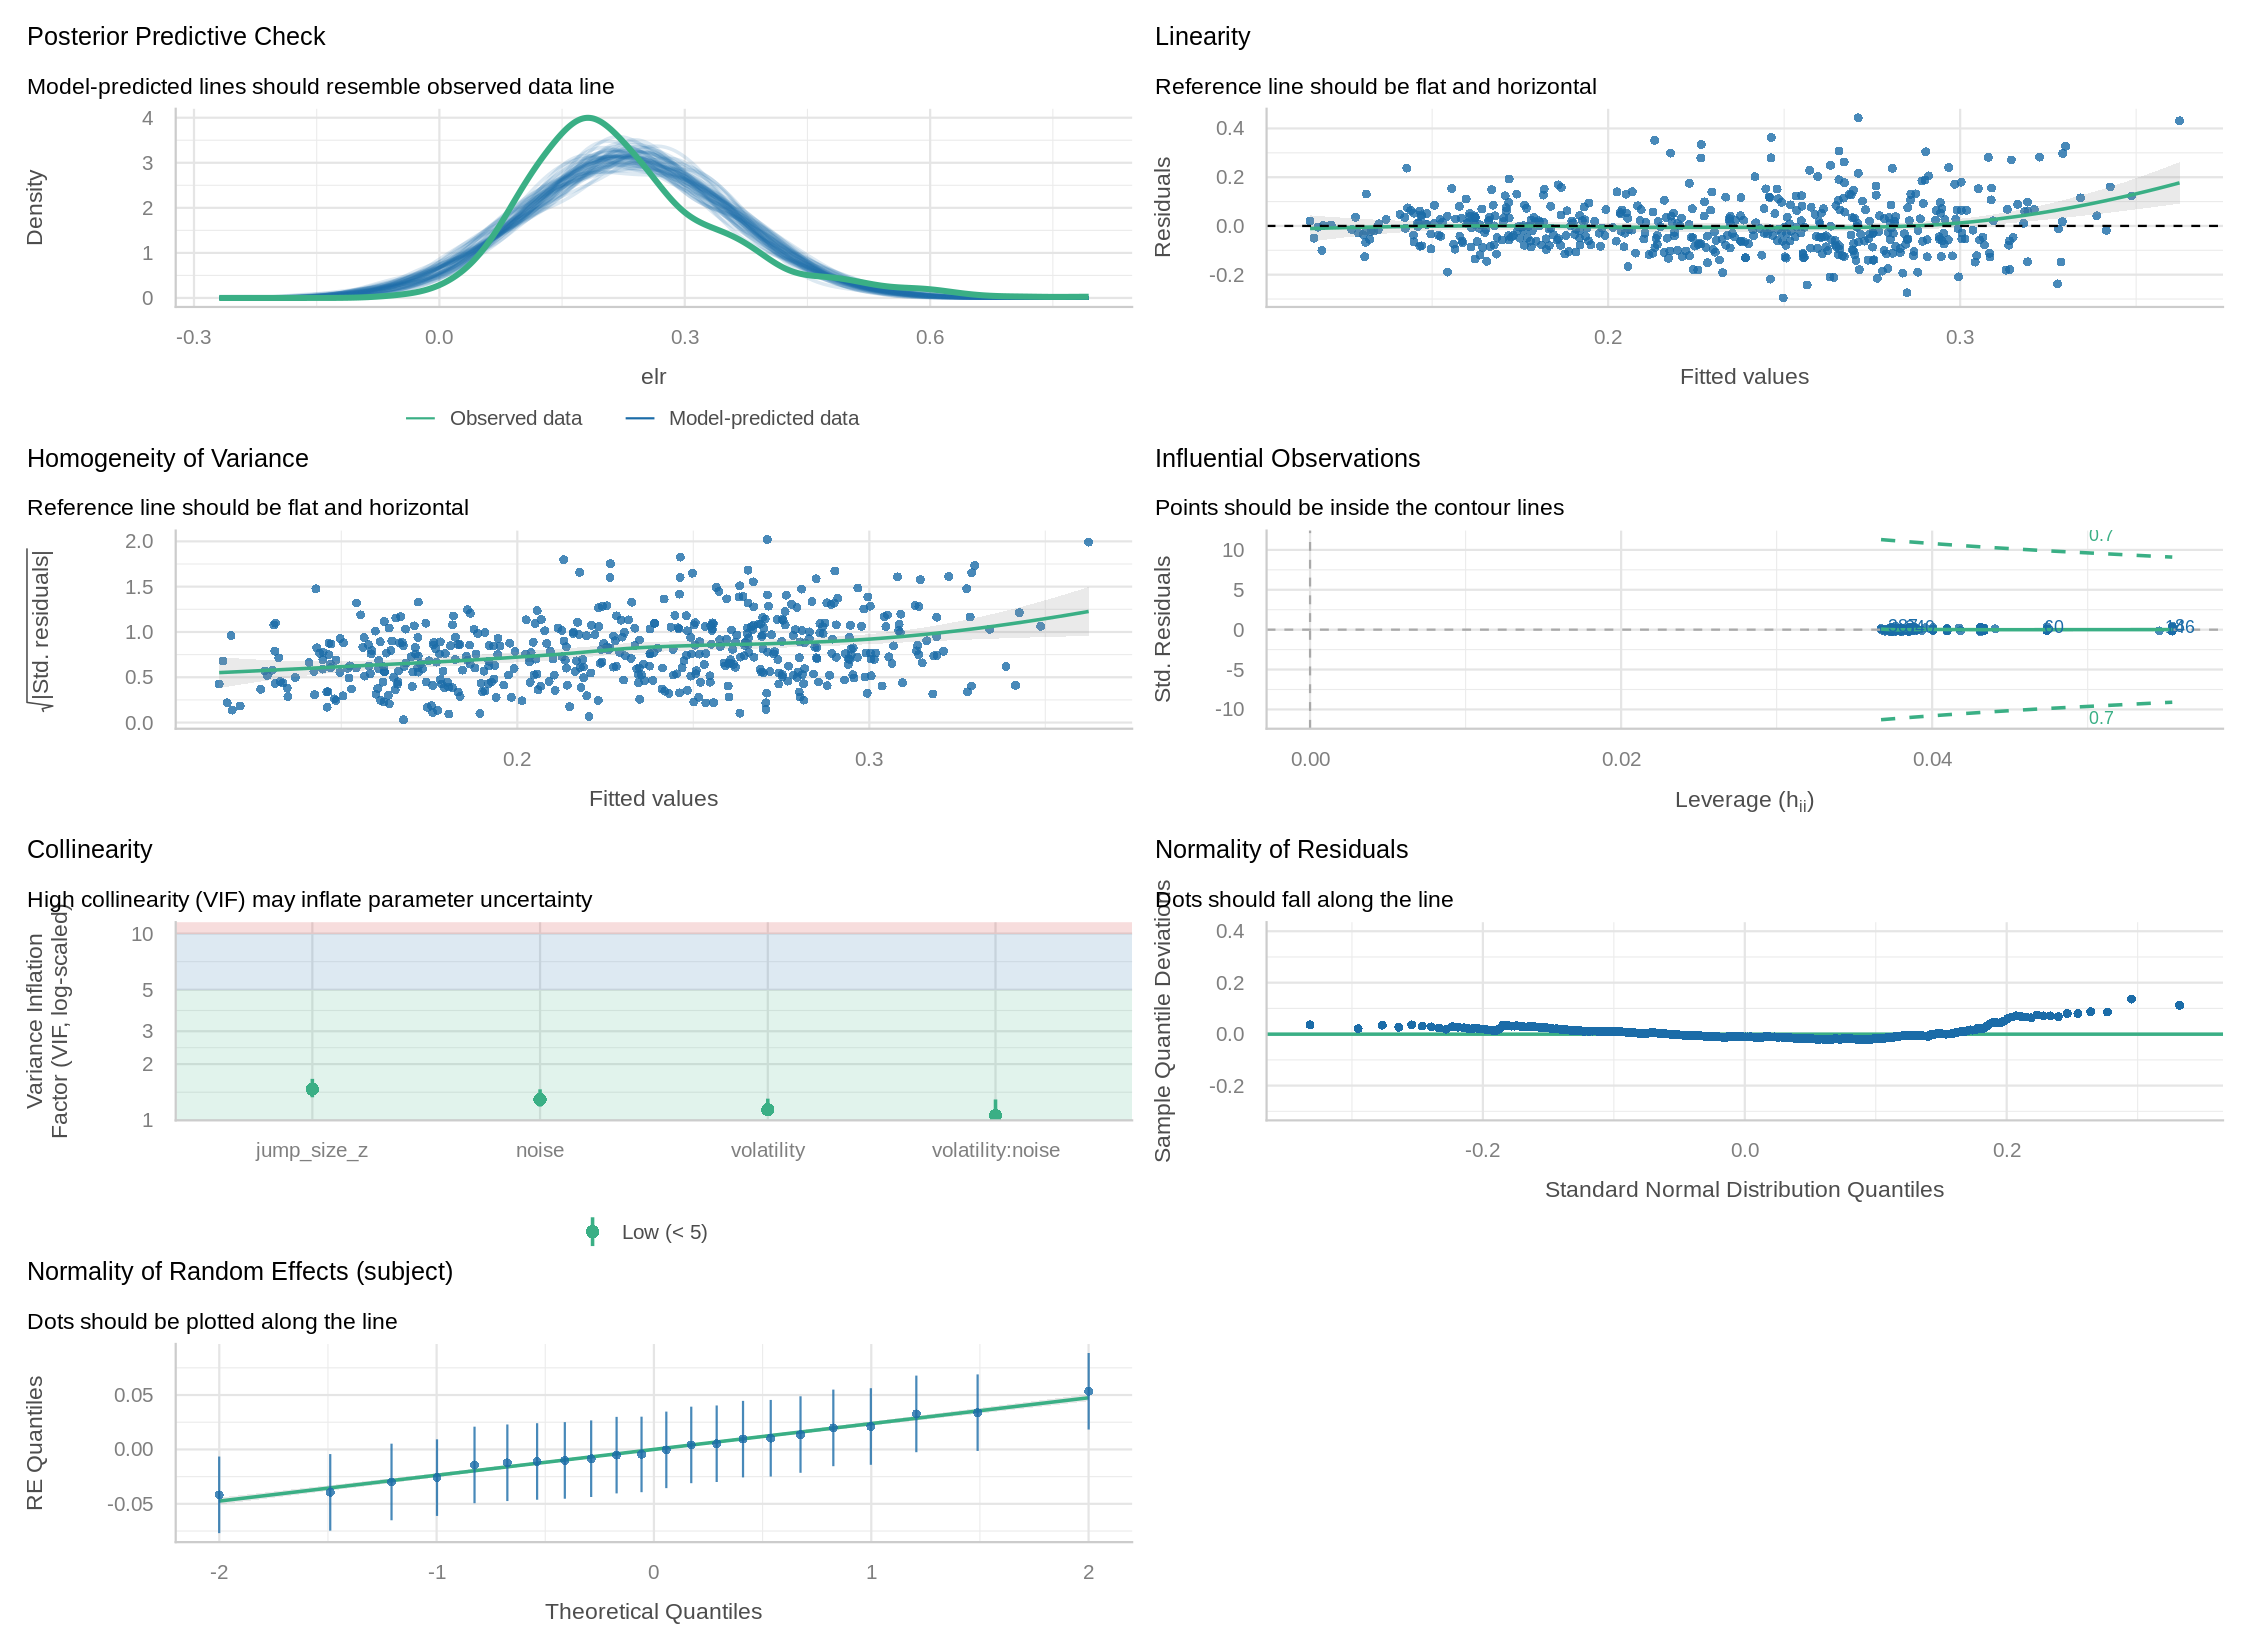

In [ ]:
options(
  repr.plot.width = 15,
  repr.plot.height = 11
)

check_model(model_elr)


## 9. Save model results


In [ ]:
fixed_effects <- as.data.frame(
  coef(
    summary(model_elr)
  )
)

fixed_effects$term <- rownames(
  fixed_effects
)

rownames(
  fixed_effects
) <- NULL


anova_table <- as.data.frame(
  anova_elr
)

anova_table$term <- rownames(
  anova_table
)

rownames(
  anova_table
) <- NULL


write_csv(
  fixed_effects,
  file.path(
    output_dir,
    "elr_fixed_effects.csv"
  )
)

write_csv(
  anova_table,
  file.path(
    output_dir,
    "elr_type3_anova.csv"
  )
)

write_csv(
  emm_elr_df,
  file.path(
    output_dir,
    "elr_estimated_marginal_means.csv"
  )
)

write_csv(
  posthoc_volatility,
  file.path(
    output_dir,
    "elr_posthoc_volatility_within_noise.csv"
  )
)

write_csv(
  posthoc_noise,
  file.path(
    output_dir,
    "elr_posthoc_noise_within_volatility.csv"
  )
)

saveRDS(
  model_elr,
  file.path(
    output_dir,
    "elr_lmm_model.rds"
  )
)

cat(
  "All outputs were saved to:",
  normalizePath(output_dir),
  "\n"
)


All outputs were saved to: /content/elr_lmm_outputs 


## 10. Optional sensitivity analysis using `elr_mean_change`

The main outcome above is `elr`, which represents the peak post-changepoint increase relative to the pre-changepoint baseline.

The file also contains `elr_mean_change`. The following optional model checks whether the conclusions are similar when the average post-changepoint change is used instead of the peak-based ELR.


In [ ]:
elr_mean_data <- dataset %>%
  filter(
    valid_for_model,
    !is.na(elr_mean_change),
    is.finite(elr_mean_change),
    !is.na(jump_size),
    is.finite(jump_size),
    !is.na(subject),
    !is.na(volatility),
    !is.na(noise)
  ) %>%
  mutate(
    jump_size_z = as.numeric(
      scale(jump_size)
    )
  )

contrasts(
  elr_mean_data$volatility
) <- contr.sum(2)

contrasts(
  elr_mean_data$noise
) <- contr.sum(3)

model_elr_mean <- lmer(
  elr_mean_change ~
    volatility * noise +
    jump_size_z +
    (1 | subject),
  data = elr_mean_data,
  REML = FALSE
)

summary(model_elr_mean)

anova(
  model_elr_mean,
  type = 3,
  ddf = "Satterthwaite"
)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: elr_mean_change ~ volatility * noise + jump_size_z + (1 | subject)
   Data: elr_mean_data

      AIC       BIC    logLik -2*log(L)  df.resid 
  -1409.7   -1371.7     713.9   -1427.7       498 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.4857 -0.5643  0.0166  0.5846  3.4722 

Random effects:
 Groups   Name        Variance  Std.Dev.
 subject  (Intercept) 1.309e-05 0.003618
 Residual             3.491e-03 0.059085
Number of obs: 507, groups:  subject, 22

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)         3.292e-02  2.748e-03  2.246e+01  11.980 3.13e-11 ***
volatility1         7.862e-03  2.805e-03  4.851e+02   2.803  0.00526 ** 
noise1              1.025e-04  3.800e-03  4.851e+02   0.027  0.97850    
noise2             -3.852e-03  4.162e-03  4.851e+02  -0.926  0.35508    
jump_size_z         3.526e-03  3

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,0.027430610,0.027430610,1,485.1118,7.8573375,0.0052642
noise,0.003929266,0.001964633,2,485.1628,0.5627576,0.5700075
jump_size_z,0.004283298,0.004283298,1,485.0676,1.2269256,0.2685547
volatility:noise,0.003335219,0.001667610,2,485.1425,0.4776770,0.6205139


## Dataset check used to build this notebook

The uploaded `elr_long.csv` contains:

- **528** total rows;
- **507** rows marked `valid_for_model = TRUE`;
- **22** participants;
- 4 sessions;
- 2 volatility levels;
- 3 noise levels.

The notebook therefore filters invalid rows before fitting the primary ELR model.
